<a href="https://colab.research.google.com/github/ChuLinh02/AdvancedMachineLearning/blob/main/DQN_for_2048_game.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Đồ án: Áp dụng Deep Q-Learning cho game 2048
**Môn học:** Học máy nâng cao  
**Nhóm thực hiện:**
1. Nguyễn Văn A - MSSV...
2. Trần Thị B - MSSV...

> **Mục tiêu đồ án:** Triển khai Vanilla DQN (Baseline) trên môi trường OpenSpiel 2048 và thực hiện các cải tiến kiến trúc (Double DQN, Dueling DQN) để so sánh hiệu suất học của Agent.

In [9]:
# Cài đặt môi trường
# Colab / notebook setup
# If running on Colab, this cell should work out of the box.

!python -V
!pip -q install --upgrade pip
!pip -q install open-spiel torch matplotlib imageio tqdm

Python 3.12.13


In [10]:
# Cài đặt thư viện
import random
import re
from collections import deque, namedtuple

import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import warnings
warnings.filterwarnings('ignore')

import pyspiel

print("PyTorch version:", torch.__version__)
print("OpenSpiel version:", pyspiel.__version__ if hasattr(pyspiel, "__version__") else "unknown")
print("CUDA available:", torch.cuda.is_available())
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

PyTorch version: 2.10.0+cpu
OpenSpiel version: 1.6.12
CUDA available: False
Device: cpu


## 1. Load and inspect OpenSpiel 2048

OpenSpiel biểu diễn trò chơi dưới dạng đối tượng `Game` và trạng thái hiện tại là `State`. Trò chơi 2048 có yếu tố ngẫu nhiên (chance nodes - các ô số 2, 4 xuất hiện ngẫu nhiên), chúng ta sẽ tự động giải quyết các node này trong wrapper.

In [11]:

game = pyspiel.load_game("2048")
state = game.new_initial_state()

game_type = game.get_type()
short_name = game_type.short_name if hasattr(game_type, "short_name") else "2048"

print("Registered game:", short_name)
print("Num distinct actions:", game.num_distinct_actions())
print("Observation tensor shape:", game.observation_tensor_shape())
print("Observation tensor size:", game.observation_tensor_size())
print("Max chance outcomes:", game.max_chance_outcomes())
print("Max game length:", game.max_game_length())
print("Min / Max utility:", game.min_utility(), game.max_utility())
print()
print("Initial state is chance node:", state.is_chance_node())
print("Initial state string:")
print(state)

Registered game: 2048
Num distinct actions: 4
Observation tensor shape: [4, 4]
Observation tensor size: 16
Max chance outcomes: 33
Max game length: 8192
Min / Max utility: 0.0 20480.0

Initial state is chance node: True
Initial state string:
    0    0    0    0
    0    0    0    0
    0    0    0    0
    0    0    0    0



## 2. Helper functions

We use a few robust helpers because OpenSpiel exposes both `observation_tensor(player)` and `observation_tensor()` variants in Python.

In [12]:

def extract_obs(state, player_id=0):
    """Return a flat float32 observation vector for the player."""
    for fn_name, args in [
        ("observation_tensor", (player_id,)),
        ("observation_tensor", tuple()),
        ("information_state_tensor", (player_id,)),
        ("information_state_tensor", tuple()),
    ]:
        fn = getattr(state, fn_name, None)
        if fn is None:
            continue
        try:
            obs = fn(*args)
            obs = np.asarray(obs, dtype=np.float32).reshape(-1)
            return obs
        except TypeError:
            pass
    raise RuntimeError("Could not extract an observation tensor from state.")


def legal_actions(state, player_id=0):
    """Return legal actions for the current player state."""
    try:
        return list(state.legal_actions(player_id))
    except TypeError:
        return list(state.legal_actions())


def sample_chance_action(state, rng):
    outcomes = state.chance_outcomes()  # list of (action, prob)
    actions, probs = zip(*outcomes)
    idx = rng.choice(len(actions), p=np.asarray(probs, dtype=np.float64))
    return actions[idx]


def auto_resolve_chance_nodes(state, rng):
    """Mutate state until it is no longer a chance node."""
    while state.is_chance_node() and not state.is_terminal():
        a = sample_chance_action(state, rng)
        state.apply_action(a)
    return state


def state_return(state, player_id=0):
    vals = state.returns()
    return float(vals[player_id]) if len(vals) > player_id else 0.0


def state_reward(state, player_id=0):
    vals = state.rewards()
    return float(vals[player_id]) if len(vals) > player_id else 0.0


def parse_board_numbers(state):
    """Best-effort text parser for showing the board as a 4x4 integer array."""
    txt = str(state)
    nums = [int(x) for x in re.findall(r"\d+", txt)]
    if len(nums) >= 16:
        nums = nums[-16:]
        return np.array(nums, dtype=np.int64).reshape(4, 4)
    return None


# Quick sanity check
test_state = game.new_initial_state()
auto_resolve_chance_nodes(test_state, np.random.default_rng(0))
print("Observation shape after resolving initial chance:", extract_obs(test_state).shape)
print("Legal actions:", legal_actions(test_state))
print("Board (best effort):")
print(parse_board_numbers(test_state))
print()
print(test_state)

Observation shape after resolving initial chance: (16,)
Legal actions: [0, 1, 2, 3]
Board (best effort):
[[0 0 0 0]
 [2 0 0 0]
 [0 0 2 0]
 [0 0 0 0]]

    0    0    0    0
    2    0    0    0
    0    0    2    0
    0    0    0    0



In [13]:

class OpenSpiel2048Env:
    def __init__(self, seed=42):
        self.game = pyspiel.load_game("2048")
        self.player_id = 0
        self.num_actions = self.game.num_distinct_actions()
        self.obs_dim = self.game.observation_tensor_size()
        self.rng = np.random.default_rng(seed)
        self.state = None

    def reset(self, seed=None):
        if seed is not None:
            self.rng = np.random.default_rng(seed)
        self.state = self.game.new_initial_state()
        auto_resolve_chance_nodes(self.state, self.rng)
        return extract_obs(self.state, self.player_id)

    def step(self, action):
        if self.state is None:
            raise RuntimeError("Call reset() before step().")
        if self.state.is_terminal():
            raise RuntimeError("Episode already ended. Call reset().")

        legal = legal_actions(self.state, self.player_id)
        if action not in legal:
            raise ValueError(f"Illegal action {action}. Legal actions: {legal}")

        prev_return = state_return(self.state, self.player_id)

        self.state.apply_action(int(action))
        auto_resolve_chance_nodes(self.state, self.rng)

        next_obs = extract_obs(self.state, self.player_id) if not self.state.is_terminal() else np.zeros(self.obs_dim, dtype=np.float32)
        new_return = state_return(self.state, self.player_id)

        reward = new_return - prev_return
        done = self.state.is_terminal()
        info = {
            "legal_actions": legal_actions(self.state, self.player_id) if not done else [],
            "state_return": new_return,
            "state_reward_raw": state_reward(self.state, self.player_id),
            "board": parse_board_numbers(self.state),
            "state_text": str(self.state),
        }
        return next_obs, float(reward), done, info

    def legal_actions(self):
        if self.state is None or self.state.is_terminal():
            return []
        return legal_actions(self.state, self.player_id)

    def render(self):
        if self.state is None:
            print("<env not reset>")
        else:
            print(self.state)

## 3. A thin OpenSpiel 2048 wrapper

This wrapper:
- auto-resolves chance nodes,
- exposes `reset()` and `step(action)`,
- returns a **flat observation vector**,
- uses **delta in cumulative return** as the immediate reward.

For 2048, the legal action set can shrink because some moves do not change the board.

In [14]:
# Demo: random rollout
env = OpenSpiel2048Env(seed=123)
obs = env.reset()

total_reward = 0.0
steps = 0
done = False

while not done and steps < 20:
    a = random.choice(env.legal_actions())
    obs, reward, done, info = env.step(a)
    total_reward += reward
    steps += 1

print("Random steps:", steps)
print("Partial return:", total_reward)
print("Legal actions now:", env.legal_actions())
env.render()

Random steps: 20
Partial return: 96.0
Legal actions now: [0, 1, 2, 3]
    0    2   16    4
    2    0   16    2
    0    0    4    2
    0    0    0    0



## 4. Replay buffer and Dueling Q-Network

**Cải tiến DUELING DQN:**
Thay vì dùng mạng MLP cơ bản (QNetwork) để tính trực tiếp giá trị $Q(s, a)$, nhóm áp dụng **Dueling Architecture**. Mạng được tách thành 2 luồng riêng biệt sau các lớp đặc trưng chung:
1. **Value stream $V(s)$**: Đánh giá trạng thái bàn cờ hiện tại tốt hay xấu. (Ví dụ: bàn cờ trống rỗng là tốt, bàn cờ kẹt cứng là xấu, bất kể hành động tiếp theo là gì).
2. **Advantage stream $A(s, a)$**: Đánh giá lợi thế của việc thực hiện hành động $a$ so với các hành động khác tại trạng thái đó.
Việc này giúp Agent học được giá trị của các trạng thái một cách độc lập với hành động, đặc biệt hữu ích trong 2048 vì nhiều khi chọn hướng nào cũng không quan trọng bằng việc bàn cờ đang có thế tốt.

In [15]:

Transition = namedtuple("Transition", ["obs", "action", "reward", "next_obs", "done", "legal_mask", "next_legal_mask"])

class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def __len__(self):
        return len(self.buffer)

    def add(self, *args):
        self.buffer.append(Transition(*args))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        return Transition(*zip(*batch))


def make_legal_mask(num_actions, legal_actions_list):
    mask = np.zeros(num_actions, dtype=np.float32)
    mask[legal_actions_list] = 1.0
    return mask


class DuelingQNetwork(nn.Module):
    def __init__(self, obs_dim, num_actions, hidden_dim=256):
        super().__init__()
        self.feature_layer = nn.Sequential(
            nn.Linear(obs_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU()
        )

        self.value_stream = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

        self.advantage_stream = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_actions)
        )

    def forward(self, x):
        features = self.feature_layer(x)
        values = self.value_stream(features)
        advantages = self.advantage_stream(features)
        qvals = values + (advantages - advantages.mean(dim=1, keepdim=True))
        return qvals


@torch.no_grad()
def masked_greedy_action(q_net, obs, legal_actions_list, num_actions, epsilon=0.0, device=DEVICE):
    if random.random() < epsilon:
        return random.choice(legal_actions_list)

    obs_t = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
    q = q_net(obs_t).squeeze(0)

    legal_mask = torch.zeros(num_actions, dtype=torch.bool, device=device)
    legal_mask[legal_actions_list] = True

    q_masked = q.masked_fill(~legal_mask, -1e9)
    action = int(torch.argmax(q_masked).item())
    return action

## 5. Training loop áp dụng Double DQN

**Giải thích cải tiến**

Vanilla DQN thường đánh giá quá cao (overestimate) giá trị Q vì nó dùng phép toán `max` trên mạng Target để vừa *chọn* hành động tốt nhất, vừa *đánh giá* hành động đó.
Để khắc phục, nhóm áp dụng **Double DQN (DDQN)** trong hàm `dqn_update`:
1. Dùng **Mạng Chính (q_net)** để tìm ra hành động tốt nhất ở trạng thái tiếp theo.
2. Dùng **Mạng Mục tiêu (target_net)** để lấy giá trị Q của chính hành động vừa được chọn đó.
Việc tách bạch này giúp tính toán Q-target ổn định và chính xác hơn, tránh bị bias.

In [16]:

# Hyperparameters
SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

NUM_EPISODES = 300          # increase to 800+ for stronger results
BUFFER_SIZE = 50_000
BATCH_SIZE = 128
GAMMA = 0.99
LR = 1e-3
TARGET_SYNC_EVERY = 250
LEARN_START = 1_000
LEARN_EVERY = 4
EPS_START = 1.0
EPS_END = 0.05
EPS_DECAY_STEPS = 20_000
MAX_STEPS_PER_EPISODE = 5_000
GRAD_CLIP = 10.0

train_env = OpenSpiel2048Env(seed=SEED)

obs_dim = train_env.obs_dim
num_actions = train_env.num_actions

# Khởi tạo Dueling Network thay vì Q-Network
q_net = DuelingQNetwork(obs_dim, num_actions).to(DEVICE)
target_net = DuelingQNetwork(obs_dim, num_actions).to(DEVICE)
target_net.load_state_dict(q_net.state_dict())
target_net.eval()

optimizer = optim.Adam(q_net.parameters(), lr=LR)
replay = ReplayBuffer(BUFFER_SIZE)

print("obs_dim =", obs_dim)
print("num_actions =", num_actions)

obs_dim = 16
num_actions = 4


In [17]:
def epsilon_by_step(step):
    frac = min(1.0, step / EPS_DECAY_STEPS)
    return EPS_START + frac * (EPS_END - EPS_START)


def dqn_update(batch):
    obs = torch.tensor(np.asarray(batch.obs), dtype=torch.float32, device=DEVICE)
    actions = torch.tensor(batch.action, dtype=torch.int64, device=DEVICE).unsqueeze(1)
    rewards = torch.tensor(batch.reward, dtype=torch.float32, device=DEVICE)
    next_obs = torch.tensor(np.asarray(batch.next_obs), dtype=torch.float32, device=DEVICE)
    dones = torch.tensor(batch.done, dtype=torch.float32, device=DEVICE)

    next_legal_mask = torch.tensor(np.asarray(batch.next_legal_mask), dtype=torch.bool, device=DEVICE)

    q_values = q_net(obs)
    q_sa = q_values.gather(1, actions).squeeze(1)

    with torch.no_grad():
        # Cải tiến: Áp dụng Double DQN

        # Dùng mạng chính q_net để chọn ra hành động tốt nhất (argmax)
        next_q_main = q_net(next_obs)
        next_q_main = next_q_main.masked_fill(~next_legal_mask, -1e9)
        best_next_actions = torch.argmax(next_q_main, dim=1).unsqueeze(1)

        # Dụng target_net để đánh giá hành động đó
        next_q_target = target_net(next_obs)
        next_max_q = next_q_target.gather(1, best_next_actions).squeeze(1)

        next_max_q = torch.where(dones > 0.5, torch.zeros_like(next_max_q), next_max_q)
        target = rewards + GAMMA * next_max_q

    loss = F.mse_loss(q_sa, target)

    optimizer.zero_grad()
    loss.backward()
    nn.utils.clip_grad_norm_(q_net.parameters(), GRAD_CLIP)
    optimizer.step()

    return float(loss.item())

In [18]:
# Loop huấn luyện chính
episode_returns = []
episode_lengths = []
loss_history = []
eval_returns = []

global_step = 0

for episode in tqdm(range(1, NUM_EPISODES + 1), desc="Training Dueling Double DNQ"):
    obs = train_env.reset(seed=SEED + episode)
    done = False
    ep_return = 0.0
    ep_len = 0

    while not done and ep_len < MAX_STEPS_PER_EPISODE:
        eps = epsilon_by_step(global_step)
        legal = train_env.legal_actions()
        legal_mask = make_legal_mask(num_actions, legal)

        action = masked_greedy_action(
            q_net=q_net,
            obs=obs,
            legal_actions_list=legal,
            num_actions=num_actions,
            epsilon=eps,
            device=DEVICE,
        )

        next_obs, reward, done, info = train_env.step(action)
        next_legal = info["legal_actions"] if not done else []
        next_legal_mask = make_legal_mask(num_actions, next_legal)

        replay.add(obs, action, reward, next_obs, done, legal_mask, next_legal_mask)

        obs = next_obs
        ep_return += reward
        ep_len += 1
        global_step += 1

        if len(replay) >= LEARN_START and global_step % LEARN_EVERY == 0:
            batch = replay.sample(BATCH_SIZE)
            loss = dqn_update(batch)
            loss_history.append(loss)

        if global_step % TARGET_SYNC_EVERY == 0:
            target_net.load_state_dict(q_net.state_dict())

    episode_returns.append(ep_return)
    episode_lengths.append(ep_len)

    if episode % 20 == 0:
        eval_env = OpenSpiel2048Env(seed=1000 + episode)
        obs_eval = eval_env.reset(seed=2000 + episode)
        done_eval = False
        ret_eval = 0.0
        steps_eval = 0
        while not done_eval and steps_eval < MAX_STEPS_PER_EPISODE:
            legal = eval_env.legal_actions()
            action = masked_greedy_action(q_net, obs_eval, legal, num_actions, epsilon=0.0, device=DEVICE)
            obs_eval, reward, done_eval, info_eval = eval_env.step(action)
            ret_eval += reward
            steps_eval += 1
        eval_returns.append((episode, ret_eval))

print("Training complete.")

Training Dueling Double DNQ:   0%|          | 0/300 [00:00<?, ?it/s]

Training complete.


## 6. Plot learning curves

Trực quan hóa tổng phần thưởng, độ dài các ván game và đồ thị Loss để kiểm chứng sự hội tụ của Agent.

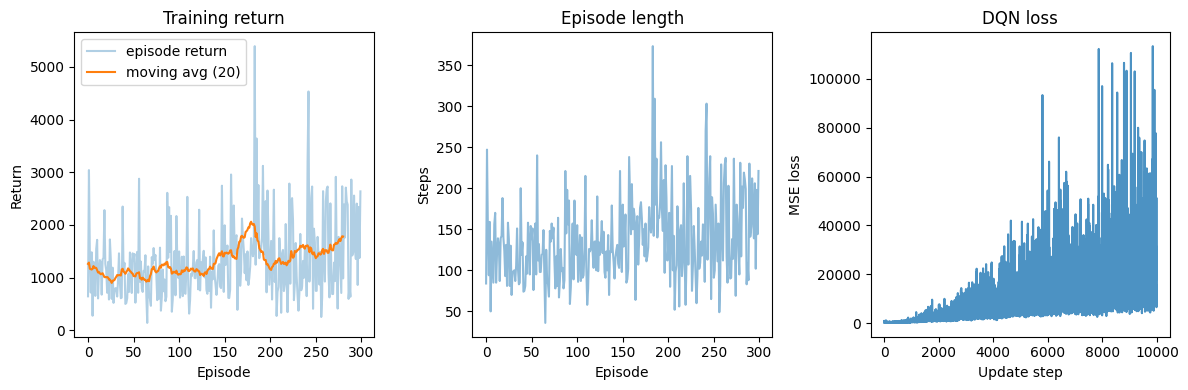

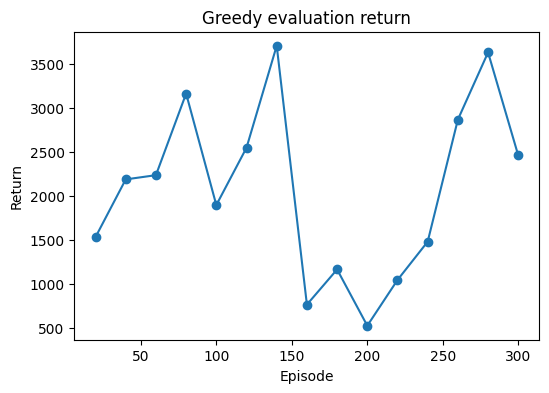

In [19]:

def moving_average(x, w=20):
    if len(x) < w:
        return np.asarray(x)
    return np.convolve(x, np.ones(w)/w, mode="valid")

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.plot(episode_returns, alpha=0.35, label="episode return")
ma = moving_average(episode_returns, 20)
plt.plot(range(len(ma)), ma, label="moving avg (20)")
plt.title("Training return")
plt.xlabel("Episode")
plt.ylabel("Return")
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(episode_lengths, alpha=0.5)
plt.title("Episode length")
plt.xlabel("Episode")
plt.ylabel("Steps")

plt.subplot(1, 3, 3)
plt.plot(loss_history, alpha=0.8)
plt.title("DQN loss")
plt.xlabel("Update step")
plt.ylabel("MSE loss")

plt.tight_layout()
plt.show()

if eval_returns:
    eval_eps, eval_vals = zip(*eval_returns)
    plt.figure(figsize=(6,4))
    plt.plot(eval_eps, eval_vals, marker="o")
    plt.title("Greedy evaluation return")
    plt.xlabel("Episode")
    plt.ylabel("Return")
    plt.show()

## 7. Evaluate a greedy policy and inspect the final board

Chạy một ván thử nghiệm với Agent hoàn thiện (epsilon = 0.0) và in ra trạng thái bàn cờ ở những bước cuối cùng.

In [20]:

eval_env = OpenSpiel2048Env(seed=999)
obs = eval_env.reset(seed=999)
done = False
greedy_return = 0.0
rollout = []

while not done and len(rollout) < MAX_STEPS_PER_EPISODE:
    legal = eval_env.legal_actions()
    action = masked_greedy_action(q_net, obs, legal, num_actions, epsilon=0.0, device=DEVICE)
    next_obs, reward, done, info = eval_env.step(action)
    rollout.append({
        "action": action,
        "reward": reward,
        "legal_actions": legal,
        "board": info["board"],
        "state_text": info["state_text"],
    })
    obs = next_obs
    greedy_return += reward

print("Greedy evaluation return:", greedy_return)
print("Rollout length:", len(rollout))
print()
eval_env.render()

Greedy evaluation return: 3256.0
Rollout length: 273

   16    2    4    2
    2   16    8    4
   64   32   16    8
  128  256   32   16



In [21]:

# Show a few last boards from the greedy rollout
n_show = min(5, len(rollout))
for i, step_info in enumerate(rollout[-n_show:], start=len(rollout)-n_show+1):
    print("=" * 60)
    print(f"Step {i} | action={step_info['action']} | reward={step_info['reward']:.1f}")
    if step_info["board"] is not None:
        print(step_info["board"])
    print(step_info["state_text"])

Step 269 | action=2 | reward=20.0
[[ 16   2   4   2]
 [  2  16   8   0]
 [ 64  32  16   4]
 [128 256  32  16]]
   16    2    4    2
    2   16    8    0
   64   32   16    4
  128  256   32   16

Step 270 | action=2 | reward=0.0
[[ 16   2   4   2]
 [  2  16   8   2]
 [ 64  32  16   4]
 [128 256  32  16]]
   16    2    4    2
    2   16    8    2
   64   32   16    4
  128  256   32   16

Step 271 | action=2 | reward=4.0
[[ 16   2   4   2]
 [  2  16   8   4]
 [ 64  32  16   4]
 [128 256  32  16]]
   16    2    4    2
    2   16    8    4
   64   32   16    4
  128  256   32   16

Step 272 | action=2 | reward=8.0
[[ 16   2   4   2]
 [  2  16   8   2]
 [ 64  32  16   8]
 [128 256  32  16]]
   16    2    4    2
    2   16    8    2
   64   32   16    8
  128  256   32   16

Step 273 | action=2 | reward=4.0
[[ 16   2   4   2]
 [  2  16   8   4]
 [ 64  32  16   8]
 [128 256  32  16]]
   16    2    4    2
    2   16    8    4
   64   32   16    8
  128  256   32   16



## 8. Save the model

You can download this checkpoint from Colab or store it to Google Drive.

In [23]:

checkpoint_path = "d3qn_openspiel_2048.pt"
torch.save(
    {
        "model_state_dict": q_net.state_dict(),
        "target_state_dict": target_net.state_dict(),
        "obs_dim": obs_dim,
        "num_actions": num_actions,
        "episode_returns": episode_returns,
        "episode_lengths": episode_lengths,
        "loss_history": loss_history,
    },
    checkpoint_path,
)
print("Saved checkpoint to:", checkpoint_path)

Saved checkpoint to: d3qn_openspiel_2048.pt
